In [1]:
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from sqlalchemy import create_engine

username = 'root'
password = '7999590423'
host = 'localhost'
port = '3306'
database = 'superstore_db'

engine = create_engine(
    f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}'
)

In [3]:
with engine.connect() as conn:
    print('Connected to MYSQL successfully')

Connected to MYSQL successfully


In [4]:
## Data Reading :

query = """
SELECT 
   o.order_id,
    o.customer_id,
    o.product_id,
    o.order_date,
    o.ship_date,
    o.ship_mode,
    o.country,
    o.state,
    o.city,
    o.region,
    o.postal_code,
    o.sales,
    o.quantity,
    o.discount,
    o.profit,
    o.shipping_cost,

    p.product_name,
    p.category,
    p.sub_category,

    c.customer_name,
    c.segment,

    COALESCE(r.Returned,'No') AS returned,
    r.market

FROM orders o
JOIN products p
ON o.product_id = p.product_id

JOIN customers c
ON o.customer_id = c.customer_id

LEFT JOIN returns r
ON o.order_id = r.`Order ID`;
"""
df = pd.read_sql(query, engine)
df

,order_id,customer_id,product_id,order_date,ship_date,ship_mode,country,state,city,region,...,discount,profit,shipping_cost,product_name,category,sub_category,customer_name,segment,returned,market
0,CG-2014-7660,PH-8790,FUR-ADV-10000002,2014-05-08,2014-05-13,Standard Class,Democratic Republic of the Congo,Kinshasa,Kinshasa,Africa,...,0.0,40.26,6.11,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Patricia Hirasaki,Home Office,No,None
1,IZ-2014-4660,TB-11190,FUR-ADV-10000002,2014-09-08,2014-09-15,Standard Class,Iraq,Baghdad,Baghdad,EMEA,...,0.0,20.13,4.03,"Advantus Photo Frame, Duo Pack",Furniture,Furnishings,Thomas Brumley,Home Office,No,None
2,RW-2012-8200,SG-10890,FUR-ADV-10000108,2012-02-20,2012-02-24,Standard Class,Rwanda,Kigali,Kigali,Africa,...,0.0,1.92,10.80,"Advantus Clock, Erganomic",Furniture,Furnishings,Susan Gilcrest,Corporate,No,None
3,LI-2011-9980,PM-9135,FUR-ADV-10000108,2011-04-13,2011-04-15,Second Class,Liberia,Montserrado,Monrovia,Africa,...,0.0,0.96,9.27,"Advantus Clock, Erganomic",Furniture,Furnishings,Peter McVee,Home Office,No,None
4,MO-2012-8110,AR-540,FUR-ADV-10000108,2012-05-10,2012-05-17,Standard Class,Morocco,Grand Casablanca,Casablanca,Africa,...,0.0,0.48,2.83,"Advantus Clock, Erganomic",Furniture,Furnishings,Andy Reiter,Consumer,No,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51290,MZ-2013-3540,EH-4005,TEC-STA-10004542,2013-04-19,2013-04-23,Standard Class,Mozambique,Sofala,Beira,Africa,...,0.0,12.00,4.68,"StarTech Calculator, Durable",Technology,Machines,Erica Hernandez,Home Office,No,None
51291,TU-2014-8160,SC-10260,TEC-STA-10004542,2014-07-07,2014-07-13,Standard Class,Turkey,Istanbul,Istanbul,EMEA,...,0.6,-18.05,1.62,"StarTech Calculator, Durable",Technology,Machines,Scott Cohen,Corporate,No,None
51292,TU-2011-790,CC-2145,TEC-STA-10004834,2011-11-03,2011-11-08,Standard Class,Turkey,Adana,Adana,EMEA,...,0.6,-107.83,13.61,"StarTech Receipt Printer, Red",Technology,Machines,Charles Crestani,Consumer,No,None
51293,NI-2013-7410,CD-1920,TEC-STA-10004834,2013-08-28,2013-09-03,Standard Class,Nigeria,Kano,Kano,Africa,...,0.7,-37.73,5.77,"StarTech Receipt Printer, Red",Technology,Machines,Carlos Daly,Consumer,No,None


In [5]:
 # Changing the data type of shipping_date and order_date column 

df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])


In [6]:
# # dropping the market column

df.drop(columns = ['market'], inplace = True)

# Discount & Profitability Analysis:

### Overall Discount Behaviour:

In [7]:
query = """
SELECT 
    ROUND(AVG(discount), 2) AS avg_discount,
    MIN(discount) AS min_discount,
    MAX(discount) AS max_discount
FROM orders;
"""

discount_behaviour = pd.read_sql(query, engine)

discount_behaviour

,avg_discount,min_discount,max_discount
0,0.14,0.0,0.85


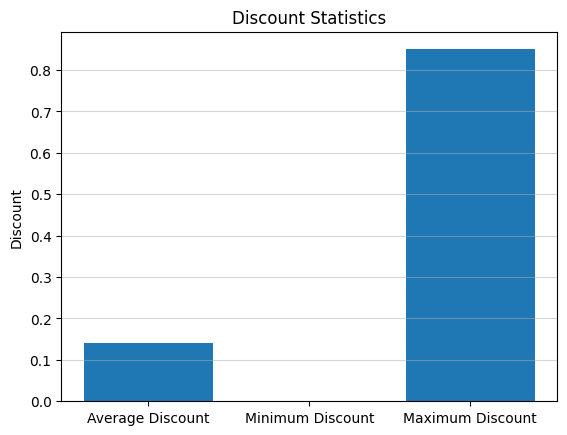

In [15]:
labels = ['Average Discount', 'Minimum Discount', 'Maximum Discount']
values = [0.14, 0.0, 0.85]

plt.bar(labels, values)

plt.title("Discount Statistics")
plt.ylabel("Discount")
plt.grid(axis = 'y', alpha = 0.5)

plt.show()

### Sales and Profit by discount levels:

In [94]:
query = """
SELECT 
    discount,
    ROUND(SUM(sales), 2) AS total_sales,
    ROUND(SUM(profit), 2) AS total_profit
FROM orders
GROUP BY discount 
ORDER BY discount; 
"""
sales_and_profit_by_discount_levels = pd.read_sql(query, engine)

sales_and_profit_by_discount_levels.head()

,discount,total_sales,total_profit
0,0.00,7253806.65,1828672.21
1,0.07,121616.87,21148.52
2,0.10,1579608.01,259065.05
3,0.15,306030.15,27376.08
4,0.17,247399.31,28163.13


### Sales at different discount levels:

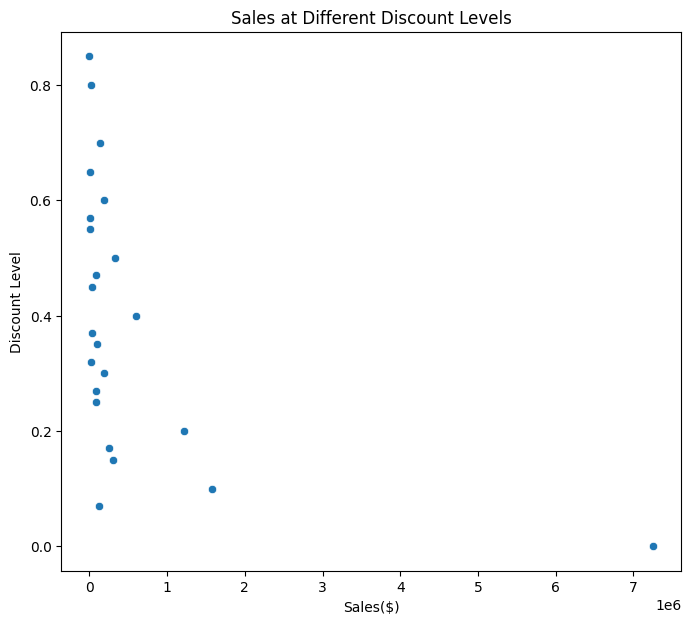

In [95]:
plt.figure(figsize = (8,7))

sns.scatterplot(x = 'total_sales',
        y = 'discount',
        data = sales_and_profit_by_discount_levels
       )

plt.title('Sales at Different Discount Levels')
plt.xlabel('Sales($)')
plt.ylabel('Discount Level')

plt.show()

### Profit at different discount levels:

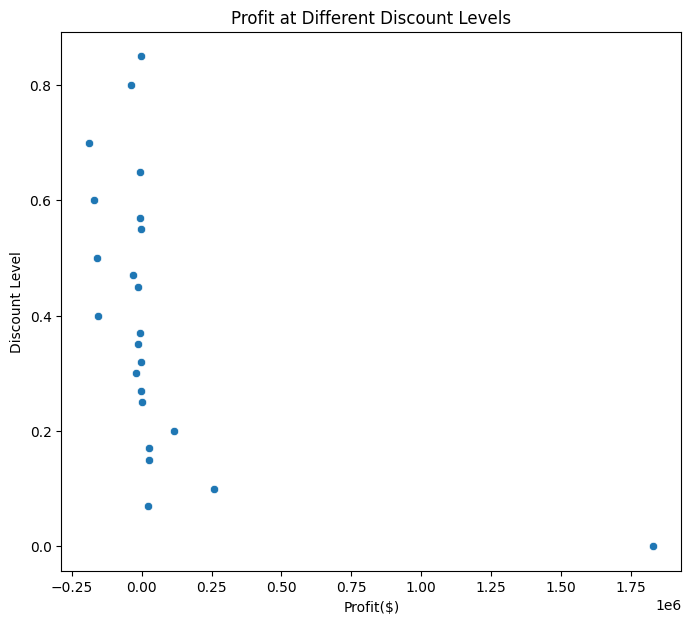

In [96]:
plt.figure(figsize = (8,7))

sns.scatterplot(x = 'total_profit',
        y = 'discount',
        data = sales_and_profit_by_discount_levels
       )

plt.title('Profit at Different Discount Levels')
plt.xlabel('Profit($)')
plt.ylabel('Discount Level')

plt.show()

* The 0% discount category shows significantly higher total sales and profit because the majority of transactions occur without discounts. This is not an outlier but reflects the natural distribution of orders across discount levels.

### Profit margin at different discount Level:

In [97]:
query = """
SELECT 
    discount,
    ROUND(SUM(profit) / SUM(sales) * 100, 2) AS profit_margin_percentage
FROM orders 
GROUP BY discount 
ORDER BY discount;
"""
profit_margin_at_different_disc_level = pd.read_sql(query, engine)

profit_margin_at_different_disc_level.head()

,discount,profit_margin_percentage
0,0.00,25.21
1,0.07,17.39
2,0.10,16.40
3,0.15,8.95
4,0.17,11.38


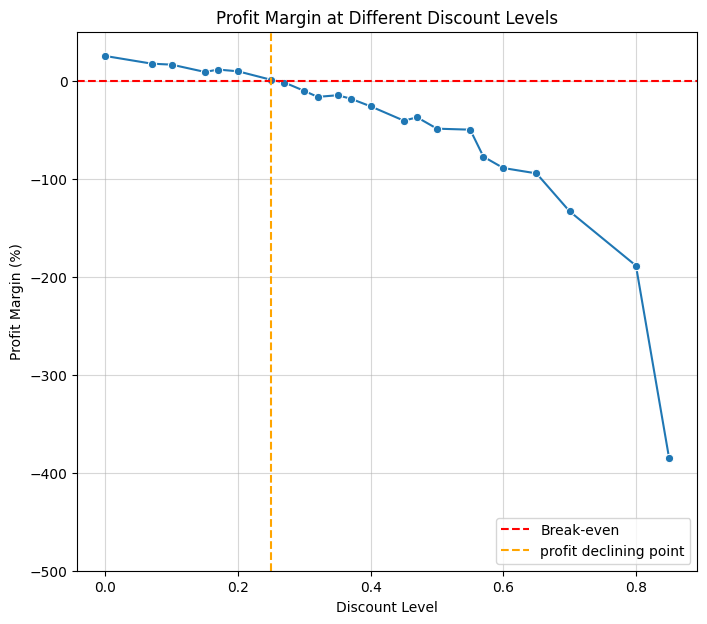

In [98]:
plt.figure(figsize=(8,7))

sns.lineplot(
    x='discount',
    y='profit_margin_percentage',
    data=profit_margin_at_different_disc_level,
    marker = 'o'

)

plt.title('Profit Margin at Different Discount Levels')
plt.xlabel('Discount Level')
plt.ylabel('Profit Margin (%)')
plt.grid(alpha = 0.5)
plt.axhline(0, color='red', linestyle='--', label='Break-even')
plt.axvline(0.25, color='orange', linestyle='--', label='profit declining point')

plt.ylim(-500, 50)

plt.legend()
plt.show()

# ax  → axis
# h   → horizontal
# line → line

### Impact of Discount Across different categories:

In [99]:
query = """
SELECT
    p.category,
    o.discount,
    SUM(o.sales) AS total_sales
FROM orders o 
JOIN products p 
ON o.product_id = p.product_id
GROUP BY p.category, o.discount
ORDER BY p.category, o.discount;
"""
discount_impact_across_different_categories = pd.read_sql(query, engine)

discount_impact_across_different_categories.head()

,category,discount,total_sales
0,Furniture,0.00,1925148.16
1,Furniture,0.07,59497.23
2,Furniture,0.10,615929.69
3,Furniture,0.15,27558.59
4,Furniture,0.20,578403.41


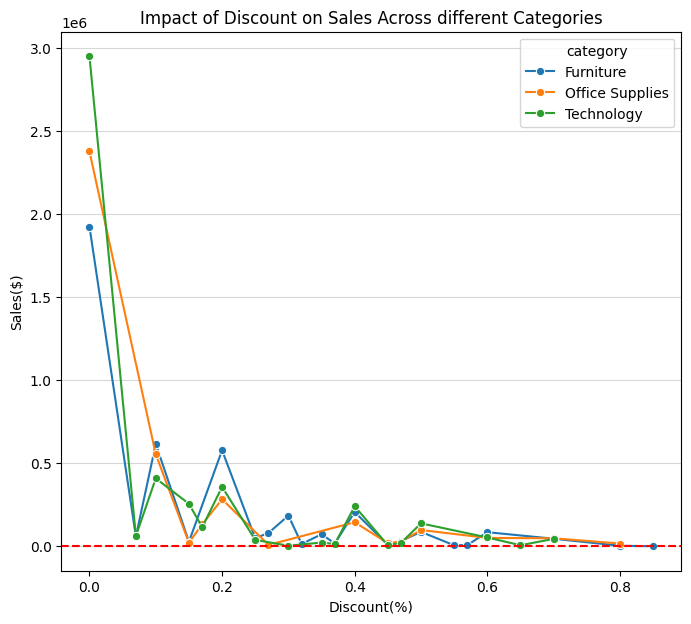

In [100]:
plt.figure(figsize = (8,7))

sns.lineplot(
    x='discount',
    y='total_sales',
    hue='category',
    marker='o',
    data=discount_impact_across_different_categories
)

plt.title('Impact of Discount on Sales Across different Categories')
plt.xlabel('Discount(%)')
plt.ylabel('Sales($)')
plt.axhline(0, color='red', linestyle='--')

plt.grid(axis = 'y',alpha = 0.5)

plt.show()

### Top 5 High Discount but low profit products

In [101]:
query = """
SELECT 
    p.product_name,
    ROUND(AVG(o.discount), 2) AS avg_discount,
    ROUND(SUM(o.sales), 2) AS total_sales,
    ROUND(SUM(o.profit), 2) AS total_profit
FROM orders o 
JOIN products p 
ON o.product_id = p.product_id
GROUP BY p.product_name
HAVING avg_discount >= 0.3
    AND total_profit < 0
ORDER BY avg_discount DESC
LIMIT 5;
"""
high_discount_low_profit_products = pd.read_sql(query, engine)
high_discount_low_profit_products

,product_name,avg_discount,total_sales,total_profit
0,"Chromcraft Training Table, Adjustable Height",0.80,38.14,-87.74
1,Eureka Disposable Bags for Sanitaire Vibra Gro...,0.80,1.62,-4.47
2,GBC VeloBinder Electric Binding Machine,0.73,496.02,-411.33
3,"Bush Westfield Collection Bookcases, Dark Cher...",0.70,90.88,-190.85
4,"Brother MFC-9340CDW LED All-In-One Printer, Co...",0.70,341.99,-319.19


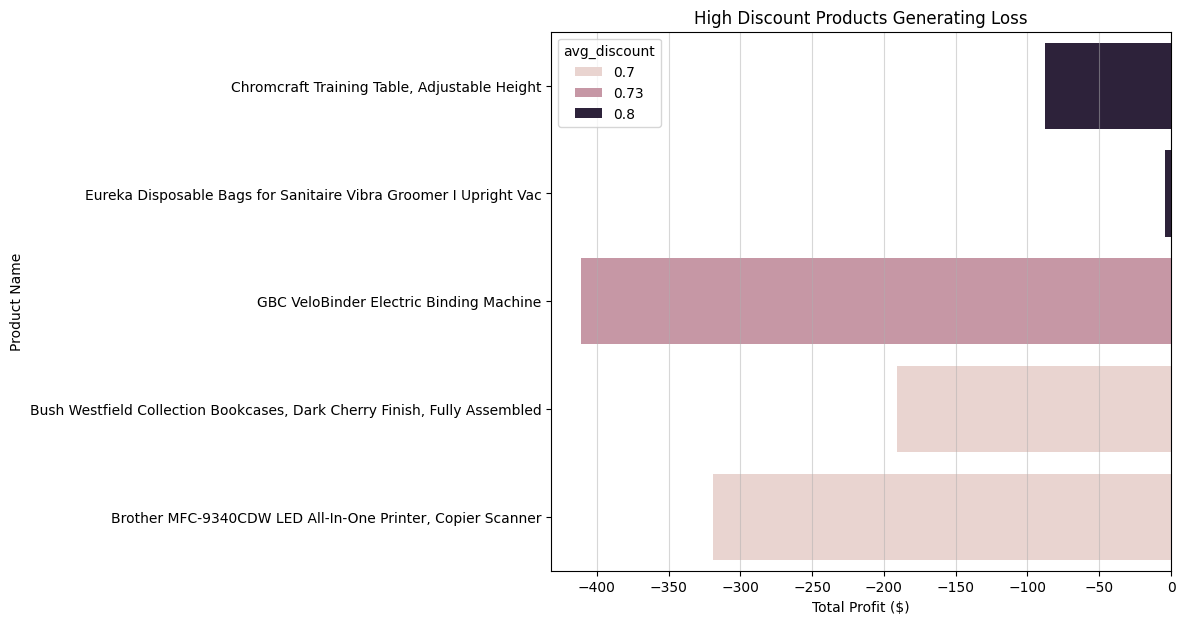

In [102]:
plt.figure(figsize=(8,7))

sns.barplot(
    x='total_profit',
    y='product_name',
    hue='avg_discount',
    data=high_discount_low_profit_products
)

plt.title('High Discount Products Generating Loss')
plt.xlabel('Total Profit ($)')
plt.ylabel('Product Name')
plt.grid(axis='x', alpha=0.5)

plt.show()

### Discount vs Volume trade-off

In [103]:
query = """
SELECT 
    discount,
    SUM(quantity) AS total_quantity_sold
FROM orders
GROUP BY Discount
ORDER BY Discount;
"""
discount_vs_volume_trade_off = pd.read_sql(query, engine)
discount_vs_volume_trade_off.head()

,discount,total_quantity_sold
0,0.00,100425.0
1,0.07,533.0
2,0.10,15417.0
3,0.15,2021.0
4,0.17,2720.0


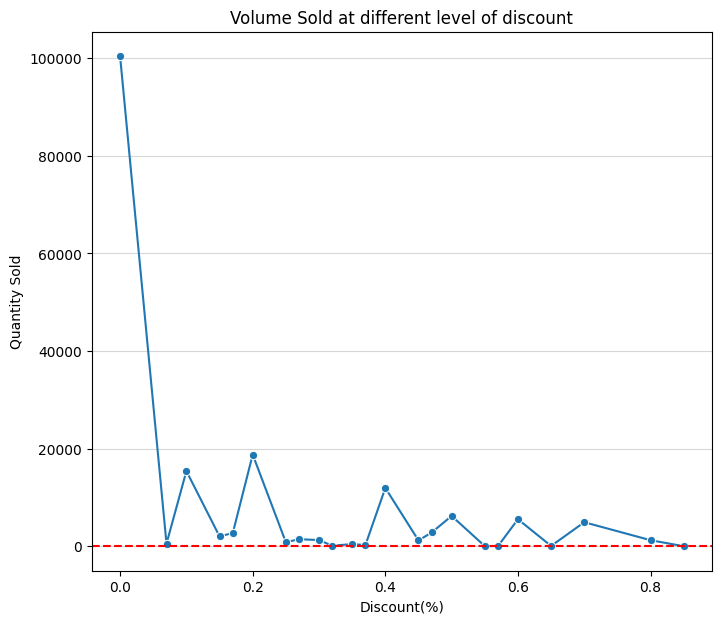

In [104]:
plt.figure(figsize=(8,7))

sns.lineplot(
    x='discount',
    y='total_quantity_sold',
    marker = 'o',
    data=discount_vs_volume_trade_off
)

plt.title('Volume Sold at different level of discount')
plt.xlabel('Discount(%)')
plt.ylabel('Quantity Sold')
plt.grid(axis='y', alpha=0.5)
plt.axhline(0, color='red', linestyle='--')


plt.show()

### Average Discount across categories :

In [107]:
query = """
SELECT
    ROUND(AVG(o.discount),2) AS avg_discount,
    p.category
FROM orders o 
JOIN products p
ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY avg_discount;
"""
Avg_discount_on_product_categories = pd.read_sql(query, engine)

Avg_discount_on_product_categories

,avg_discount,category
0,0.14,Office Supplies
1,0.14,Technology
2,0.17,Furniture


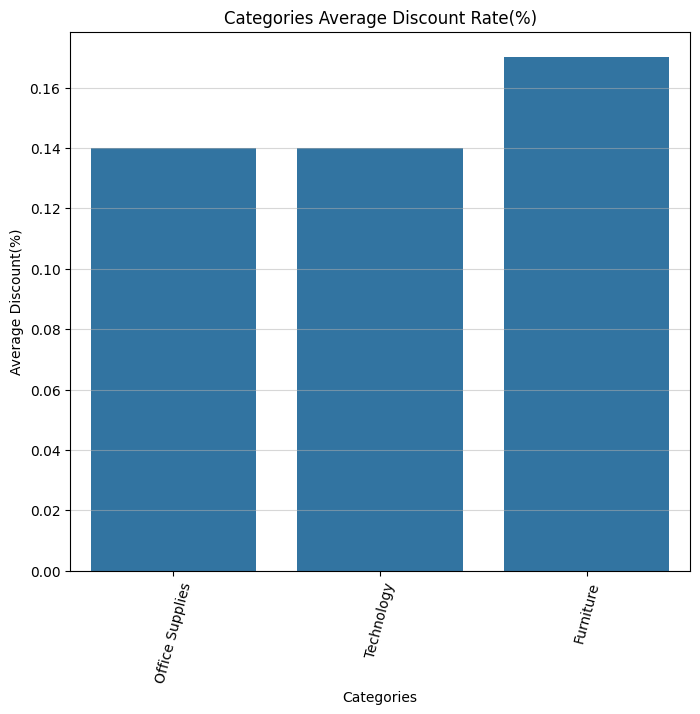

In [109]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'category',
            y = 'avg_discount',
            data = Avg_discount_on_product_categories
           )

plt.title('Categories Average Discount Rate(%)')
plt.xlabel('Categories')
plt.ylabel('Average Discount(%)')
plt.xticks(rotation = 75)
plt.grid(axis = 'y', alpha = 0.5)

plt.show()


### Average Discount by Product Sub-Categories:

In [110]:
query = """
SELECT
    ROUND(AVG(o.discount),2) AS avg_discount,
    p.sub_category
FROM orders o 
JOIN products p
ON o.product_id = p.product_id
GROUP BY p.sub_category
ORDER BY avg_discount;
"""
Avg_discount_on_product_sub_categories = pd.read_sql(query, engine)

Avg_discount_on_product_sub_categories

,avg_discount,sub_category
0,0.11,Paper
1,0.12,Art
2,0.12,Labels
3,0.12,Accessories
4,0.12,Copiers
5,0.13,Supplies
6,0.13,Envelopes
7,0.14,Fasteners
8,0.14,Appliances
9,0.14,Storage


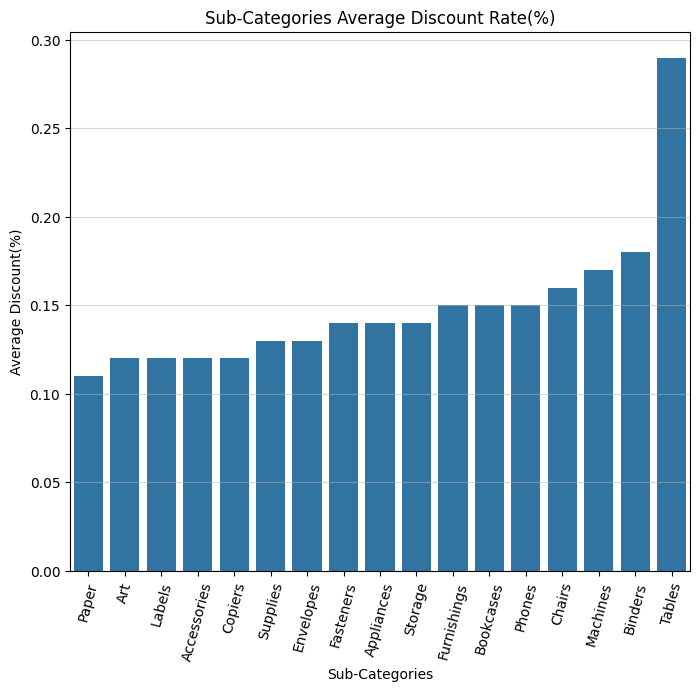

In [112]:
plt.figure(figsize = (8,7))

sns.barplot(x = 'sub_category',
            y = 'avg_discount',
            data = Avg_discount_on_product_sub_categories
           )

plt.title('Sub-Categories Average Discount Rate(%)')
plt.xlabel('Sub-Categories')
plt.ylabel('Average Discount(%)')
plt.xticks(rotation = 75)
plt.grid(axis = 'y', alpha = 0.5)

plt.show()


# Summary :

### Key insights of Discount and Profitability Analysis

### 1. The Relationship Between Discounts and Sales
* **Lower is better for Sales:** The charts show that most sales happen when discounts are low (between 0% and 20%). 
* **High discounts don't help much:** As discounts go higher (above 30%), the total number of items sold and the total money earned actually drop. Giving a 80% discount does not mean you will sell more items.

### 2. The Profit "Danger Zone"
* **The 25% Rule:** This is the most important finding. The data shows that once a discount goes above **25%**, the company starts **losing money** on that sale.
* **Negative Profit Margin:** At very high discount levels (like 80%), the profit margin drops as low as -400%. This means the company is paying a lot of money just to get rid of the product.

### 3. Discounts by Category
* **Furniture is the most discounted:** On average, Furniture has higher discount rates than Technology or Office Supplies.
* **Sub-Category Leaders:** **Tables** receive the highest average discounts (nearly 30%), followed by Binders and Machines. This explains why these categories often struggle to stay profitable.

### 4. Products Losing the Most Money
* **High-Loss Items:** Certain products like the **"GBC VeloBinder"** and **"Bush Westfield Bookcases"** are generating huge losses. 
* **The Reason:** These specific products are being sold with average discounts of **70% to 80%**, which is way past the "Break-even" point of 25%.